<a href="https://colab.research.google.com/github/Kavishka2401/CustomerChurnPredictionSystem/blob/master/1_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Loading the Dataset**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data=pd.read_csv('/content/drive/MyDrive/Customer_Churn_Data.csv')

## **Understanding the dataset**

In [ ]:
data.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TotalCharges_numeric
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,29.85
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.5,No,1889.50
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,108.15
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,1840.75
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,151.65


In [ ]:
data.shape

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customerID            7043 non-null   object 
 1   gender                7043 non-null   object 
 2   SeniorCitizen         7043 non-null   int64  
 3   Partner               7043 non-null   object 
 4   Dependents            7043 non-null   object 
 5   tenure                7043 non-null   int64  
 6   PhoneService          7043 non-null   object 
 7   MultipleLines         7043 non-null   object 
 8   InternetService       7043 non-null   object 
 9   OnlineSecurity        7043 non-null   object 
 10  OnlineBackup          7043 non-null   object 
 11  DeviceProtection      7043 non-null   object 
 12  TechSupport           7043 non-null   object 
 13  StreamingTV           7043 non-null   object 
 14  StreamingMovies       7043 non-null   object 
 15  Contract             

In [ ]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
data.isnull().sum()

In [ ]:
print(type("TotalChargers"))

<class 'str'>


In [ ]:
data.duplicated().sum()

In [ ]:
data['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [ ]:
data['Churn'].value_counts(normalize=True)

,proportion
Churn,
No,0.73463
Yes,0.26537


In [4]:
print(data['gender'].value_counts())
print(data['SeniorCitizen'].value_counts())
print(data['Partner'].value_counts())
print(data['Dependents'].value_counts())
print(data['PhoneService'].value_counts())
print(data['MultipleLines'].value_counts())
print(data['InternetService'].value_counts())
print(data['OnlineSecurity'].value_counts())
print(data['OnlineBackup'].value_counts())
print(data['DeviceProtection'].value_counts())
print(data['TechSupport'].value_counts())
print(data['StreamingTV'].value_counts())
print(data['StreamingMovies'].value_counts())
print(data['Contract'].value_counts())
print(data['PaperlessBilling'].value_counts())
print(data['PaymentMethod'].value_counts())

gender
Male      3555
Female    3488
Name: count, dtype: int64
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64
Partner
No     3641
Yes    3402
Name: count, dtype: int64
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
PhoneService
Yes    6361
No      682
Name: count, dtype: int64
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64
DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64
TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: c

In [ ]:
# 1. Create a new numeric column for TotalCharges
data['TotalCharges_numeric'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

# 2. Check missing values in the new numeric column
missing_total_charges = data['TotalCharges_numeric'].isnull().sum()
print(f"Missing values in TotalCharges_numeric after conversion: {missing_total_charges}")

# 3. Check for duplicates
duplicate_rows = data.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

data.describe()

Missing values in TotalCharges_numeric after conversion: 11
Number of duplicate rows: 0


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges_numeric
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


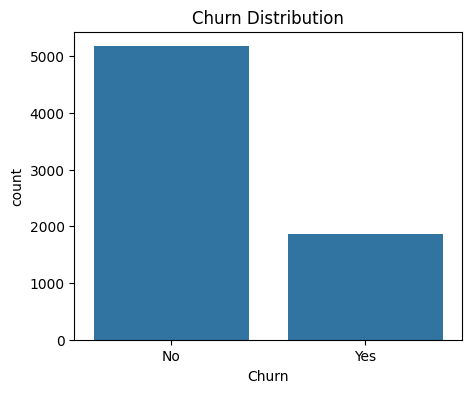

In [ ]:
plt.figure(figsize=(5,4))
sns.countplot(x='Churn', data=data)
plt.title("Churn Distribution")
plt.show()

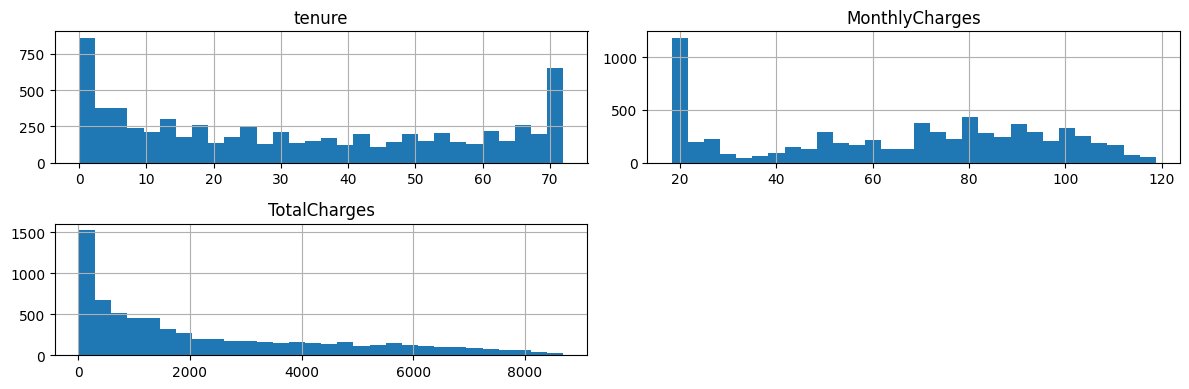

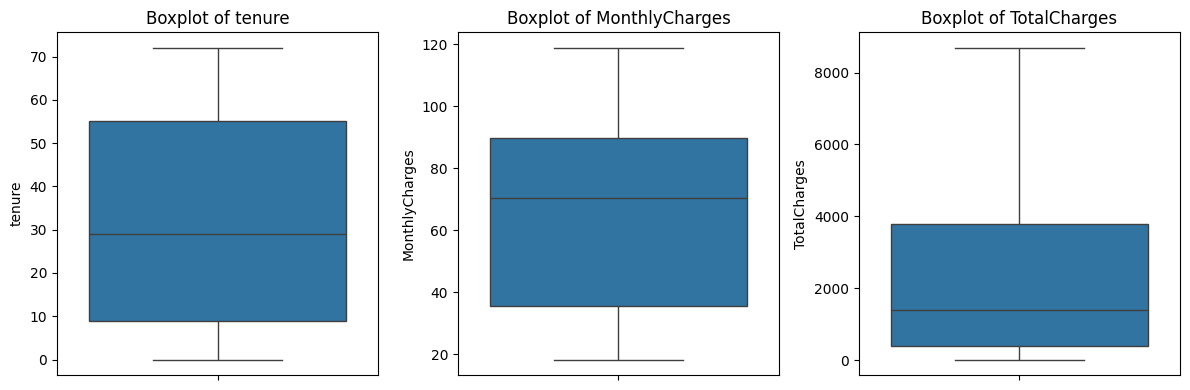

In [ ]:
num_cols = ['tenure','MonthlyCharges','TotalCharges']

# Histograms
data[num_cols].hist(figsize=(12,4), bins=30)
plt.tight_layout()
plt.show()

# Boxplots
plt.figure(figsize=(12,4))
for i, col in enumerate(num_cols):
    plt.subplot(1,3,i+1)
    sns.boxplot(y=data[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

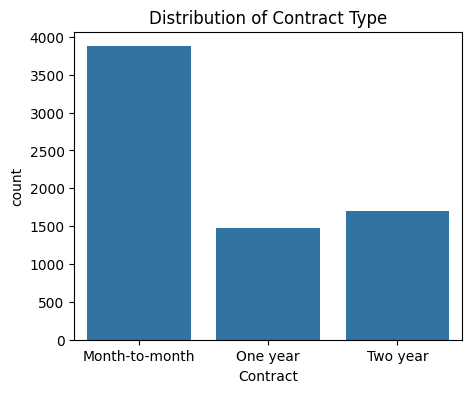

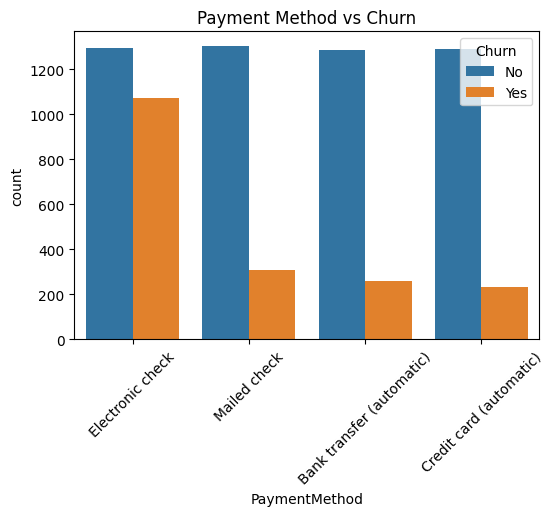

In [ ]:
#*****************# ---------------------------
# 1.3.3 Key Categorical Variable Distribution
# ---------------------------
# Optional: Contract
plt.figure(figsize=(5,4))
sns.countplot(x='Contract', data=data)
plt.title("Distribution of Contract Type")
plt.show()

# PaymentMethod vs Churn (important insight)
plt.figure(figsize=(6,4))
sns.countplot(x='PaymentMethod', hue='Churn', data=data)
plt.title("Payment Method vs Churn")
plt.xticks(rotation=45)
plt.show()

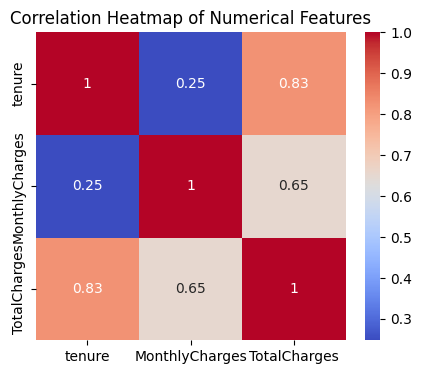

In [ ]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
plt.figure(figsize=(5,4))
sns.heatmap(data[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

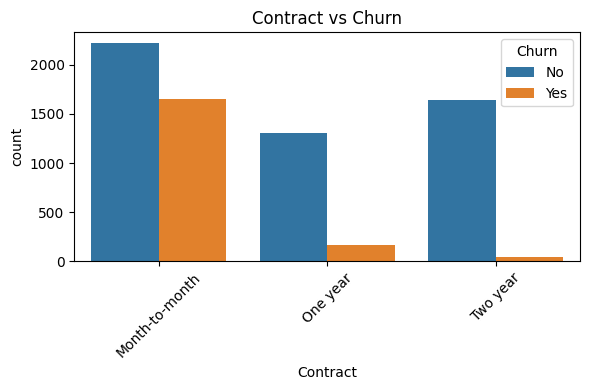

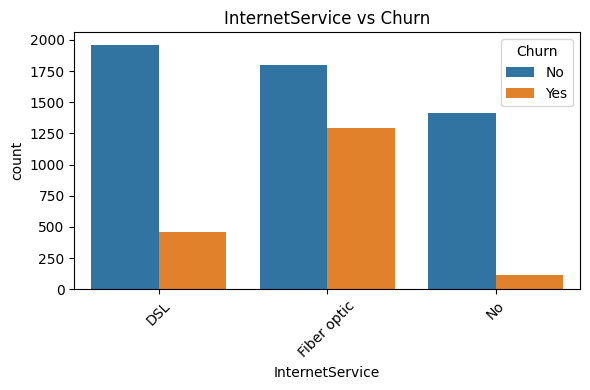

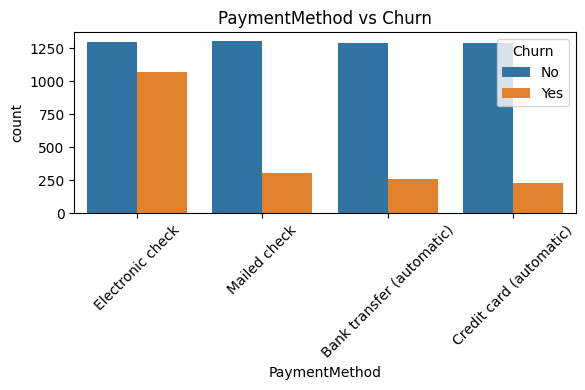

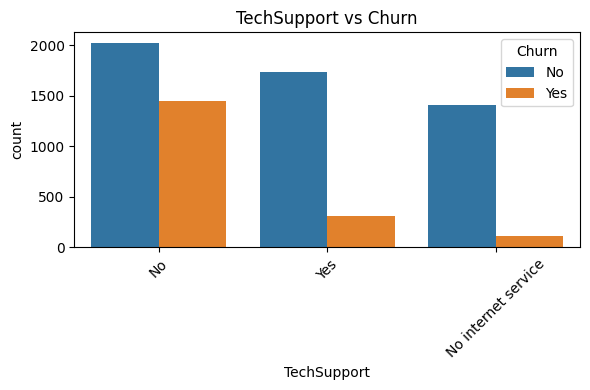

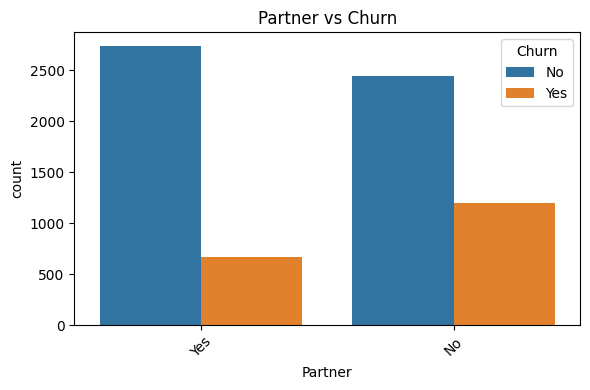

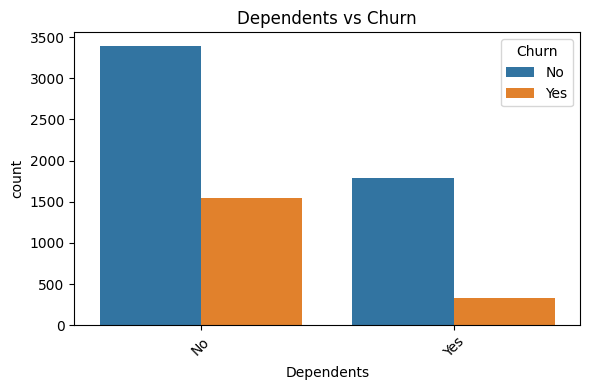

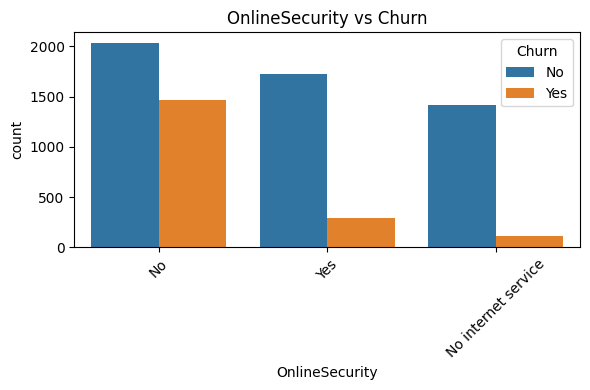

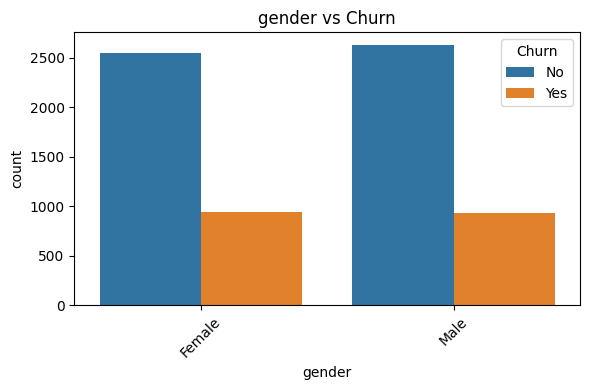

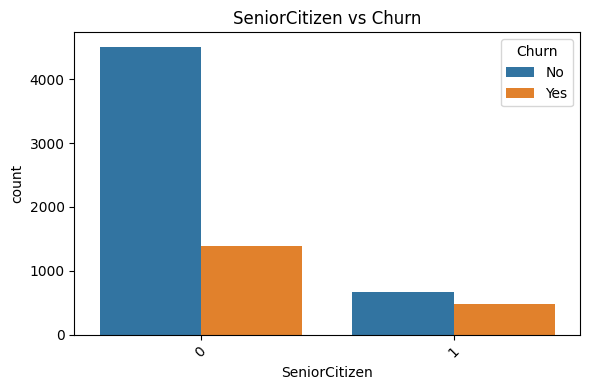

In [7]:
categorical_features = ['Contract', 'InternetService', 'PaymentMethod',
                        'TechSupport', 'Partner', 'Dependents', 'OnlineSecurity','gender','SeniorCitizen']

for col in categorical_features:
    plt.figure(figsize=(6,4))
    sns.countplot(data=data, x=col, hue='Churn')
    plt.title(f"{col} vs Churn")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


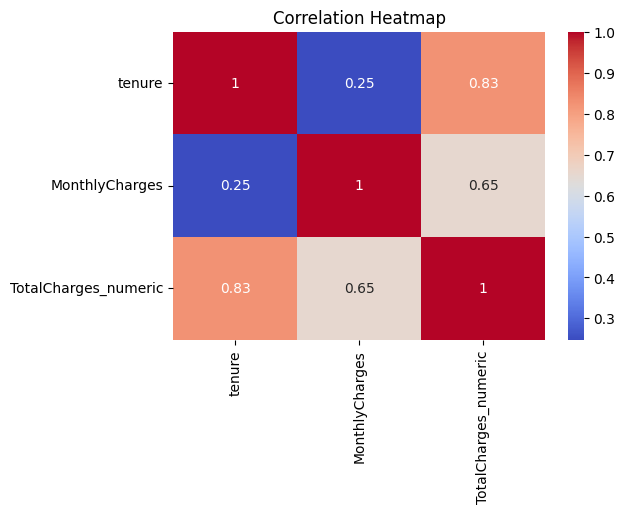

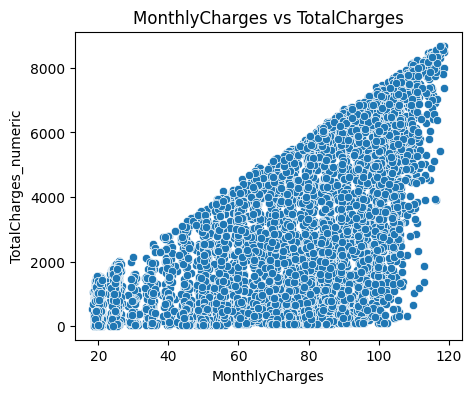

In [ ]:
# Correlation heatmap
plt.figure(figsize=(6,4))
sns.heatmap(data[['tenure', 'MonthlyCharges', 'TotalCharges_numeric']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Scatter plot
plt.figure(figsize=(5,4))
sns.scatterplot(x='MonthlyCharges', y='TotalCharges_numeric', data=data)
plt.title("MonthlyCharges vs TotalCharges")
plt.show()

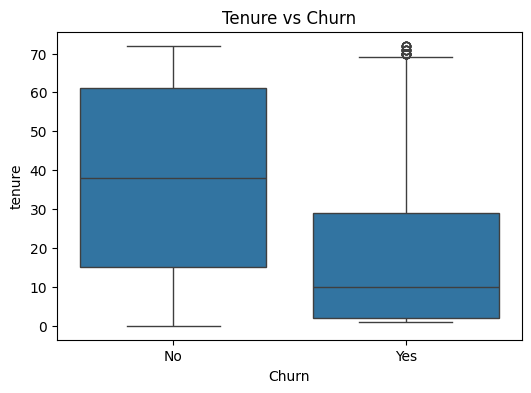

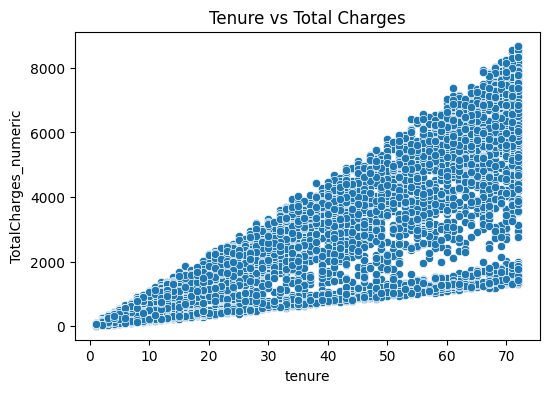

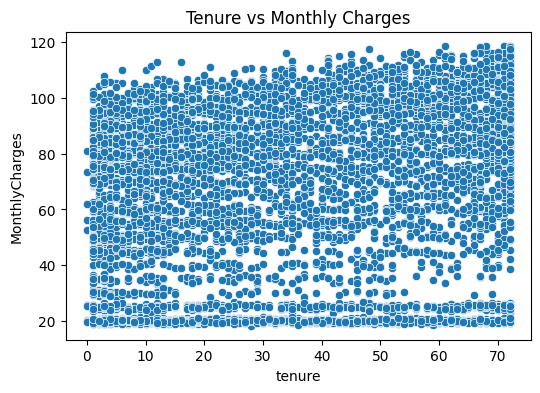

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='tenure', data=data)
plt.title("Tenure vs Churn")
plt.show()
# Scatter: tenure vs TotalCharges_numeric
plt.figure(figsize=(6,4))
sns.scatterplot(x='tenure', y='TotalCharges_numeric', data=data)
plt.title("Tenure vs Total Charges")
plt.show()

# Scatter: tenure vs MonthlyCharges
plt.figure(figsize=(6,4))
sns.scatterplot(x='tenure', y='MonthlyCharges', data=data)
plt.title("Tenure vs Monthly Charges")
plt.show()